<a href="https://colab.research.google.com/github/Kavia-M/Data_science_course-Intellipaat/blob/main/Python/Classwork/Trainers_notes/Machine_Learning/Logistic_Regression_(05_08_2025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Good Morning Everyone Guys let us wait for everyone to join the session we will be starting the session by 7:08 AM

z = b0 + b1x1 + b2x2 ---- bnxn

sigmoid(z) = 1/1+e^(-z)

proability > 0.5 -- class = 1
proability <= 0.5 -- class = 0

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/bank-additional-full_final (3).csv')

In [ ]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

# Exploratory Data Analysis

1. Null values
2. Duplicates
3. outliers
4. Label Encoding

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


# less null values or less than 30 percent has null values -- drop

# Many null values then we fill the null values with mean median mode


# fill mean when we are dealing with continous values


# fill median when you are dealing with columns in which the values are in order ascending / descending


# fill mode when dealing with categorical columns

In [ ]:
df.duplicated().sum()

np.int64(1784)

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.duplicated().sum()

np.int64(0)

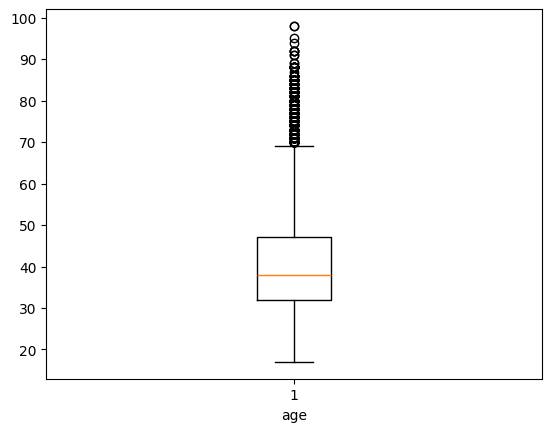

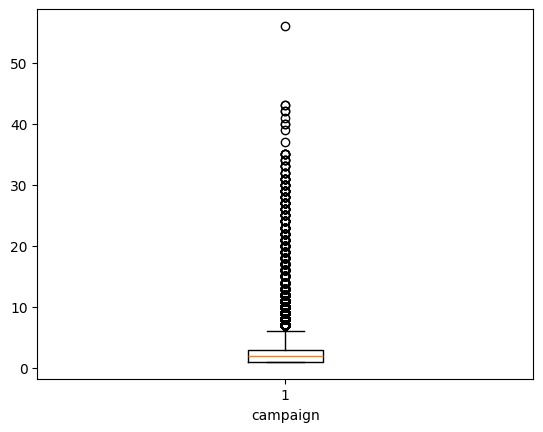

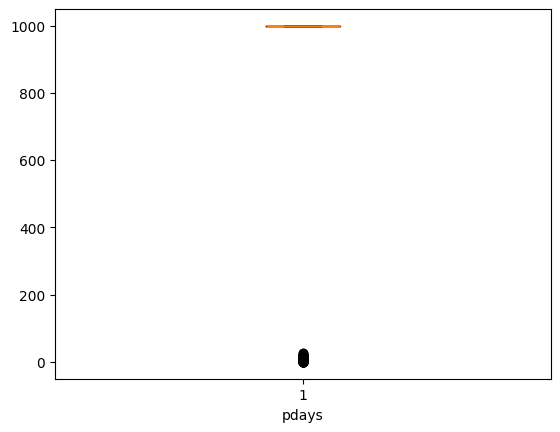

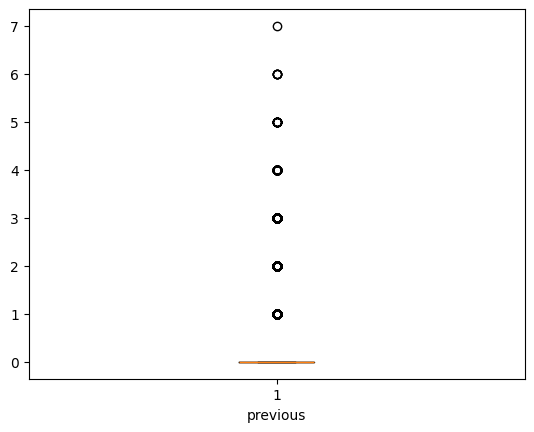

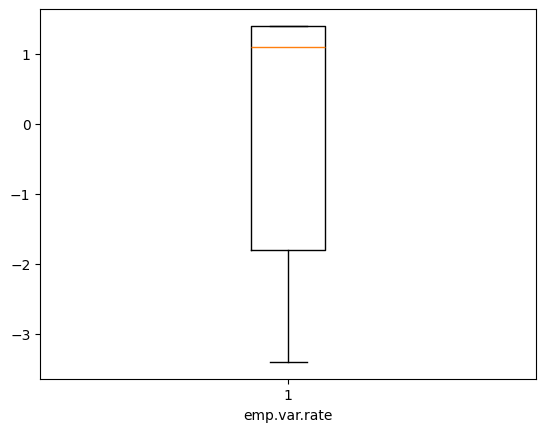

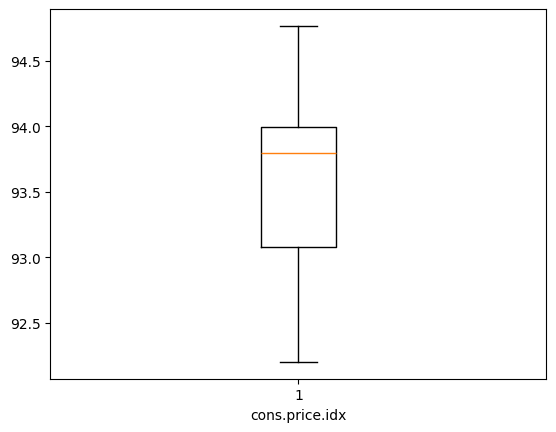

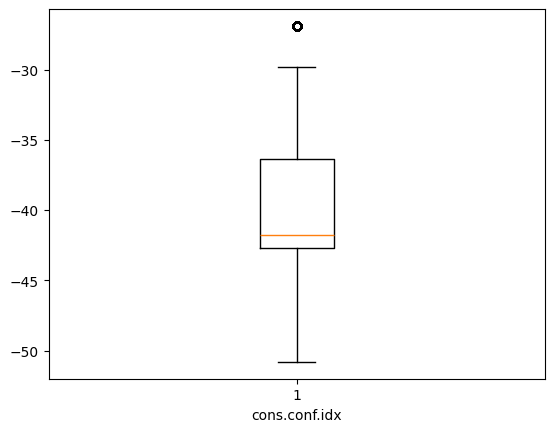

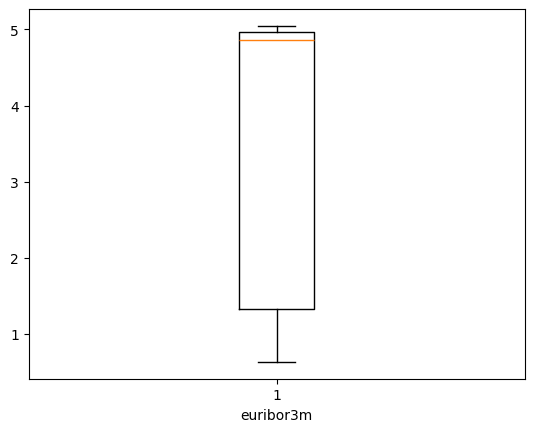

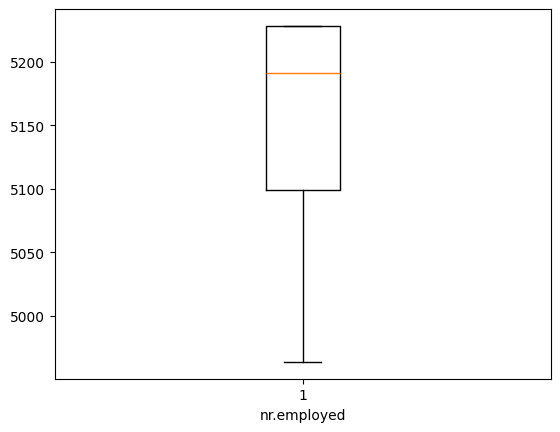

In [ ]:
# Outliers

for col in df.columns:
  if df[col].dtype != 'object':
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
df['pdays'].value_counts()

,count
pdays,
999,37890
3,438
6,412
4,118
9,64
2,61
7,60
12,58
10,52


In [ ]:
df['previous'].value_counts()

,count
previous,
0,33858
1,4484
2,752
3,216
4,70
5,18
6,5
7,1


In [ ]:
out_col = ['age','campaign','cons.conf.idx']

for col in out_col:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  df = df[(df[col] <= upper_bound) & (df[col] >= lower_bound)]



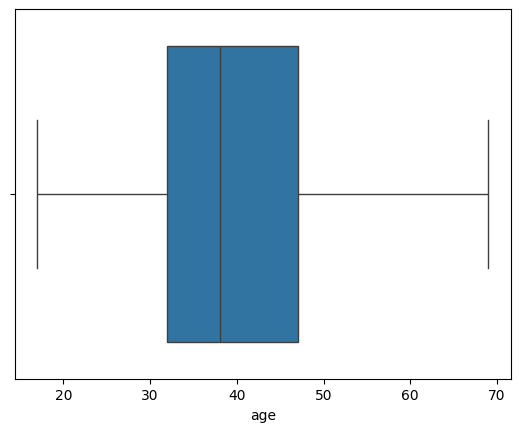

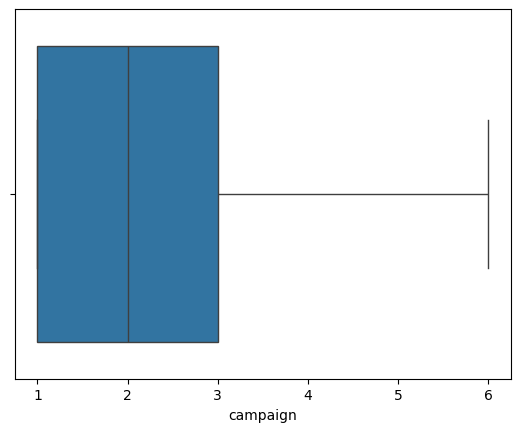

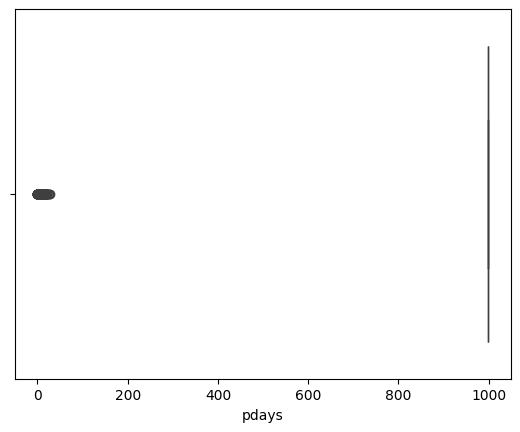

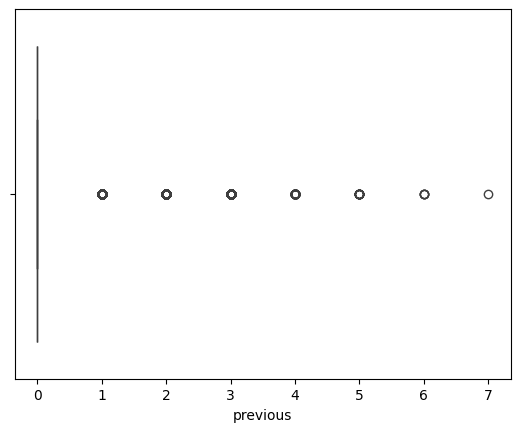

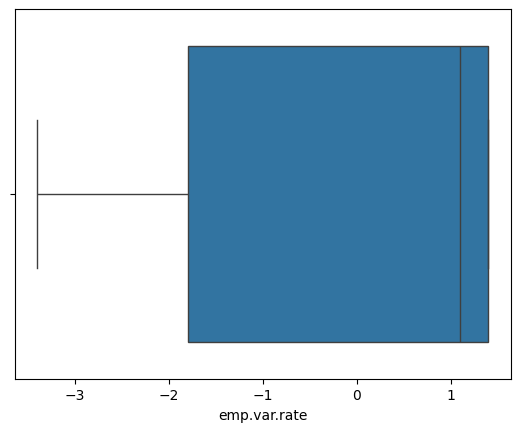

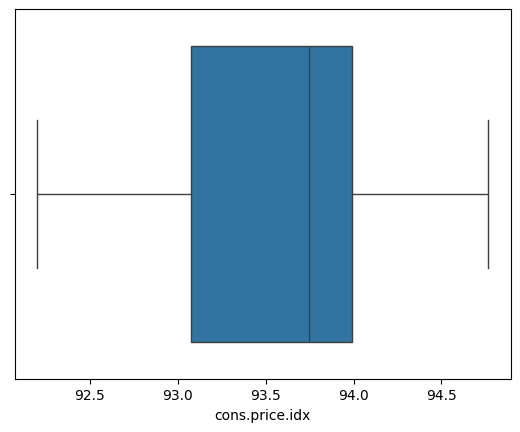

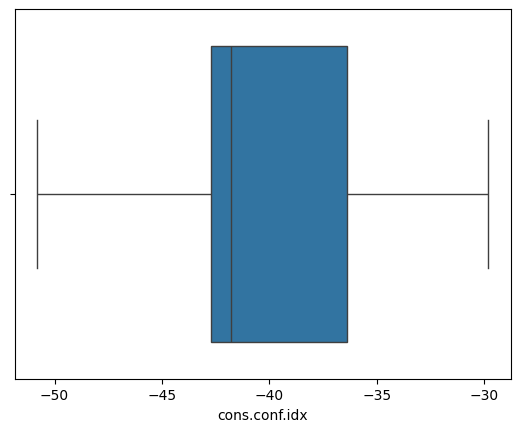

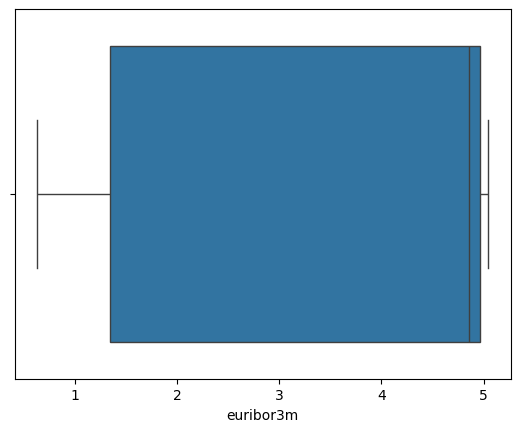

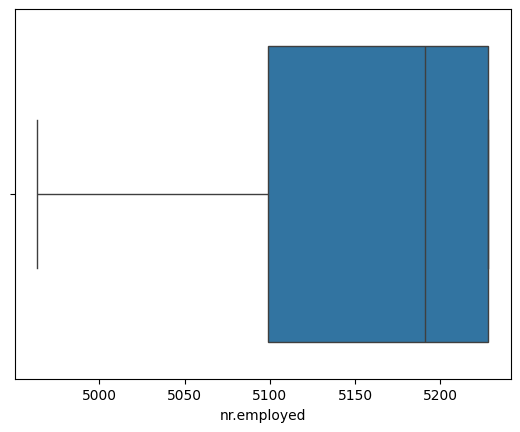

In [ ]:
# Outliers
import seaborn as sns
for col in df.columns:
  if df[col].dtype != 'object':
    sns.boxplot(x = df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
# Label encoding : convert each category to a unique integer
# one hot encoding (Nominal) : it will create binary columns for each category
# use when : Nominal (non - ordered) categories
# ordinal encoding (ordered categorical value) : similar to label encoding but you define the order

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
  if (df[col].dtype == 'object'):
    df[col] = le.fit_transform(df[col])

In [ ]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,37,0,1,6,0,2,0,0,7,0,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41182,29,10,2,0,0,2,0,0,7,0,1,9,1,2,-1.1,94.767,-50.8,1.028,4963.6,0
41184,46,1,1,5,0,0,0,0,7,0,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,5,1,6,0,2,0,0,7,0,2,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0


In [ ]:
data = pd.DataFrame({'color':['red','blue','green','green','red']})

one_hot = pd.get_dummies(data , columns = ['color'] , drop_first = False)

In [ ]:
one_hot

,color_blue,color_green,color_red
0,False,False,True
1,True,False,False
2,False,True,False
3,False,True,False
4,False,False,True


In [ ]:
data

,color
0,red
1,blue
2,green
3,green
4,red


In [ ]:
one_hot = one_hot.astype(int)

In [ ]:
one_hot

,color_blue,color_green,color_red
0,0,0,1
1,1,0,0
2,0,1,0
3,0,1,0
4,0,0,1


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

new_data = pd.DataFrame({'education': ['high shool','bachelor','masters','phd']})


order = [['high shool','bachelor','masters','phd']]

encoder = OrdinalEncoder(categories = order)

new_data['education_encoded'] = encoder.fit_transform(new_data[['education']])

print(new_data)

    education  education_encoded
0  high shool                0.0
1    bachelor                1.0
2     masters                2.0
3         phd                3.0


In [ ]:
# Feature selection
# model building

In [ ]:
correlation_mat = df.corr()

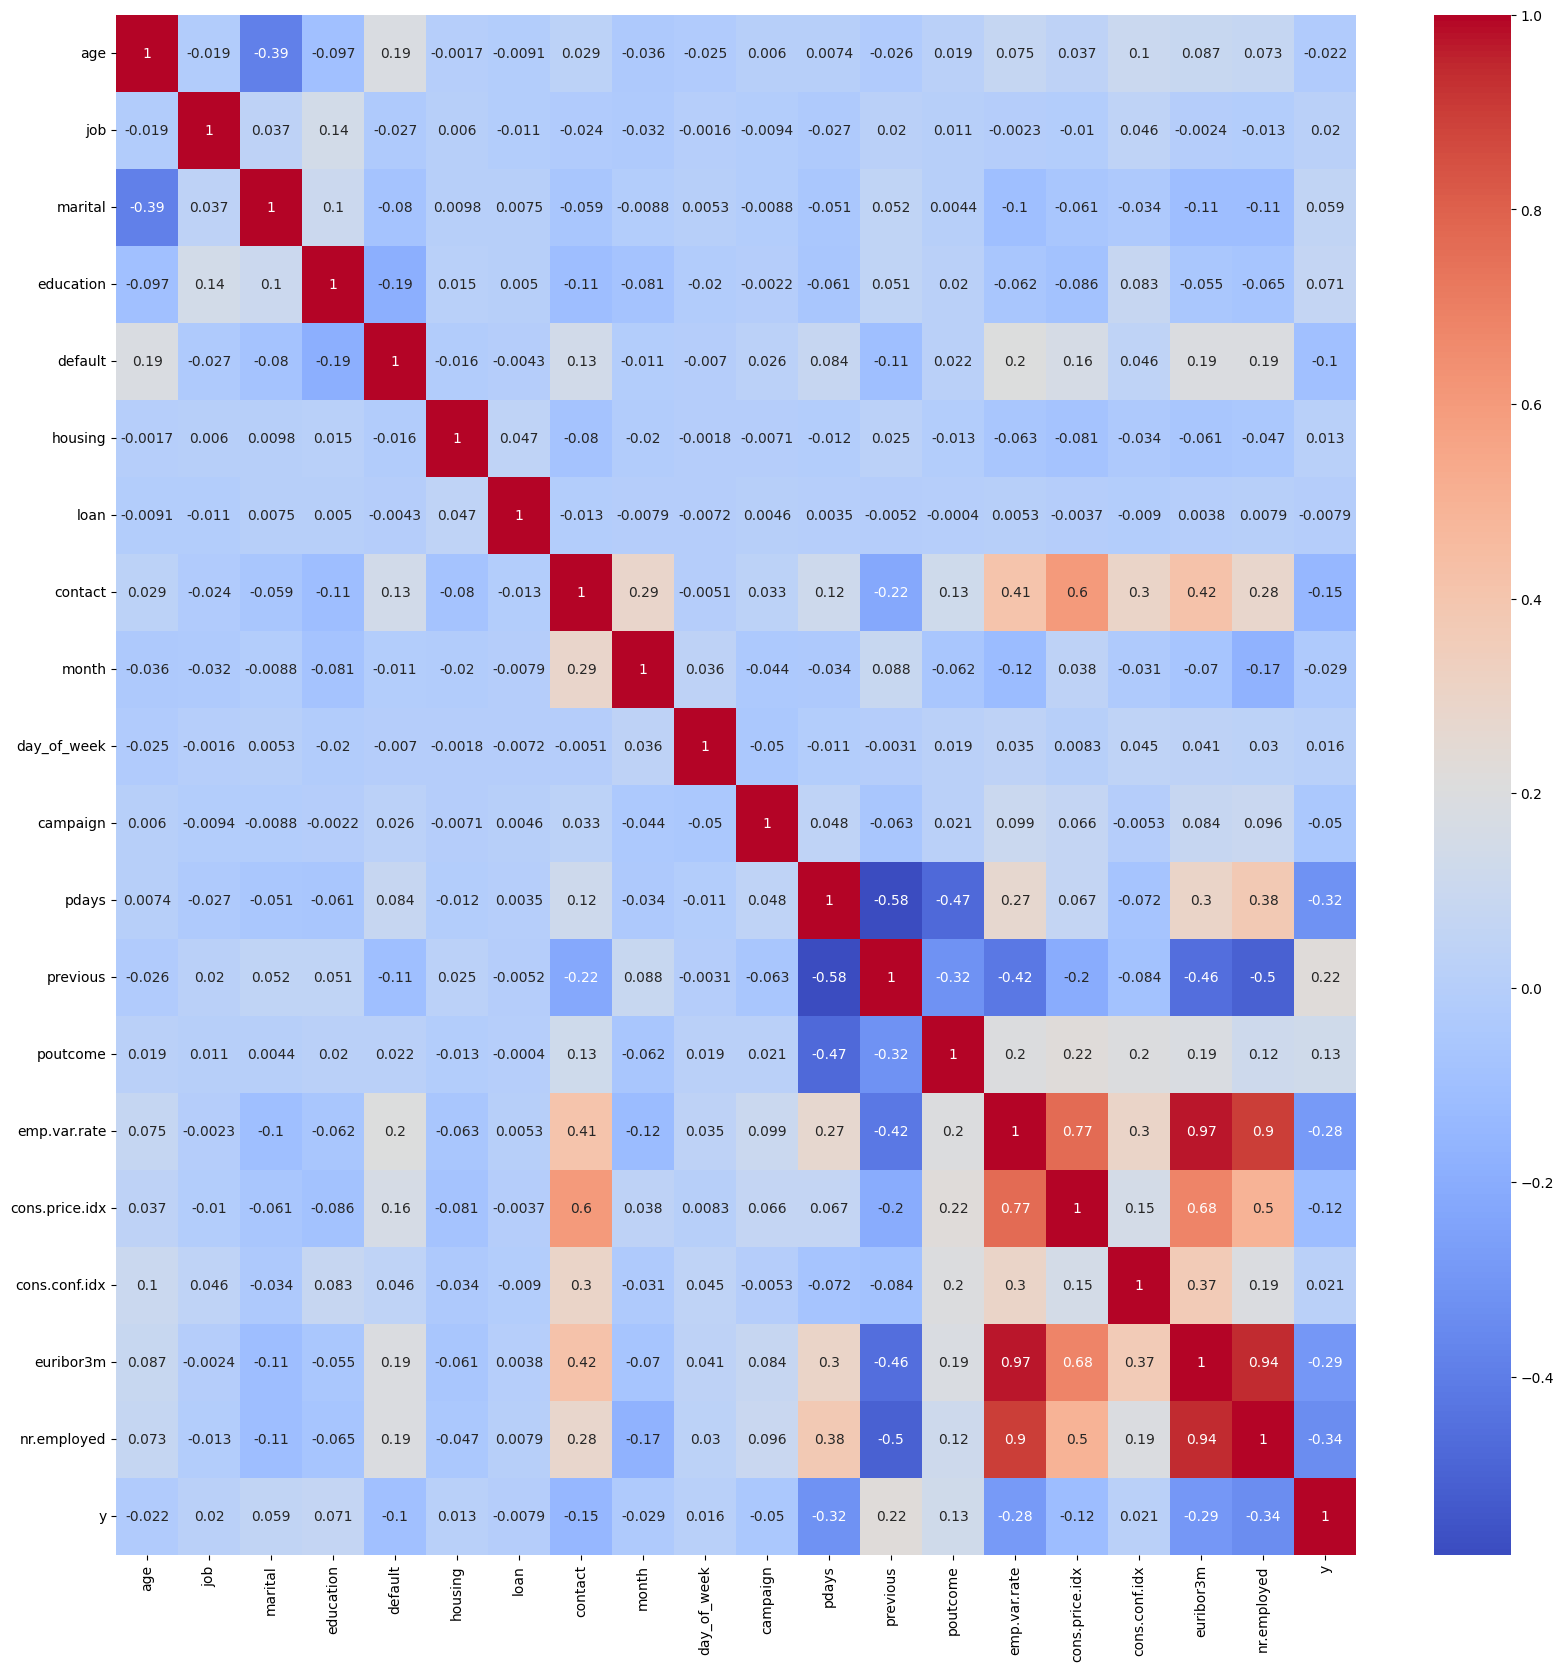

In [ ]:
plt.figure(figsize = (20,20))
sns.heatmap(correlation_mat , annot = True,cmap = 'coolwarm')
plt.show()

# VIF - Variance Inflation Factor

It is a Multicollinearity Detection Method in Feature selection

Multicollinerity means that two or more independent feature are highly correalted with each other


It will quantify how much each feature is correlated with other features in a dataset.


1. x1,x2,x3 -- independent variables

2. y -- dependent variables

step 1) Regress x1 on all the other independent variables

3. y =mx + c , y = m1x1 + m2x2 + m3x3

x1 = m2x2 + m3x3 + c  --- 0.82
x2 = m1x1 + m3x3 + c
x3 = m1x1 + m2x2 + c


step 2 ) computer R2 value of the regression -- This will tell how other features are predicting x1 , x2 and x3

step 3 ) plug in the values of r2 in the vif formula

vif(x1) = 1/ (1-r2)


vif = 1 -- No mulitcolllinearity

vif = 1-5 Moderate accepatable

vif > 5 - high multicollinearity

In [ ]:
# Variance Inflation Factor

x = df.drop('y', axis =1) # only independent variables
y = df['y'] # dependent variable

In [ ]:
x

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,3,1,0,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
1,57,7,1,3,1,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
2,37,7,1,3,0,2,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
3,40,0,1,1,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
4,56,7,1,3,0,0,2,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,37,0,1,6,0,2,0,0,7,0,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6
41182,29,10,2,0,0,2,0,0,7,0,1,9,1,2,-1.1,94.767,-50.8,1.028,4963.6
41184,46,1,1,5,0,0,0,0,7,0,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6
41185,56,5,1,6,0,2,0,0,7,0,2,999,0,1,-1.1,94.767,-50.8,1.028,4963.6


In [ ]:
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
41181,1
41182,0
41184,0
41185,0


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor



In [ ]:
vif_df = pd.DataFrame()

In [ ]:
x.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed'],
      dtype='object')

In [ ]:
vif_df['Features'] = x.columns

In [ ]:
vif_df

,Features
0,age
1,job
2,marital
3,education
4,default
5,housing
6,loan
7,contact
8,month
9,day_of_week


In [ ]:
vif_df['Multicollinearity'] = [variance_inflation_factor(x.values,i) for i in range (len(x.columns))]

In [ ]:
vif_df

,Features,Multicollinearity
0,age,21.966070
1,job,2.114551
2,marital,5.649477
3,education,4.533743
4,default,1.413486
5,housing,2.200634
6,loan,1.217609
7,contact,2.935270
8,month,6.604837
9,day_of_week,3.084861


In [ ]:
for i in range(len(x.columns)):
  vif = variance_inflation_factor(x.values,i)
  print(f'vif for {x.columns[i]} is {vif} and ')
  print('x.values (Features)')
  print(x.values)

# x.values - pass the whole feature matrix (2D Array)
# i - tell which column (feature) to treat as dependent variable

vif for age is 21.966070454402285 and 
x.values (Features)
[[ 5.6000e+01  3.0000e+00  1.0000e+00 ... -3.6400e+01  4.8570e+00
   5.1910e+03]
 [ 5.7000e+01  7.0000e+00  1.0000e+00 ... -3.6400e+01  4.8570e+00
   5.1910e+03]
 [ 3.7000e+01  7.0000e+00  1.0000e+00 ... -3.6400e+01  4.8570e+00
   5.1910e+03]
 ...
 [ 4.6000e+01  1.0000e+00  1.0000e+00 ... -5.0800e+01  1.0280e+00
   4.9636e+03]
 [ 5.6000e+01  5.0000e+00  1.0000e+00 ... -5.0800e+01  1.0280e+00
   4.9636e+03]
 [ 4.4000e+01  9.0000e+00  1.0000e+00 ... -5.0800e+01  1.0280e+00
   4.9636e+03]]
vif for job is 2.1145506549496322 and 
x.values (Features)
[[ 5.6000e+01  3.0000e+00  1.0000e+00 ... -3.6400e+01  4.8570e+00
   5.1910e+03]
 [ 5.7000e+01  7.0000e+00  1.0000e+00 ... -3.6400e+01  4.8570e+00
   5.1910e+03]
 [ 3.7000e+01  7.0000e+00  1.0000e+00 ... -3.6400e+01  4.8570e+00
   5.1910e+03]
 ...
 [ 4.6000e+01  1.0000e+00  1.0000e+00 ... -5.0800e+01  1.0280e+00
   4.9636e+03]
 [ 5.6000e+01  5.0000e+00  1.0000e+00 ... -5.0800e+01  1.0280

In [ ]:
x.drop('nr.employed',axis = 1 , inplace = True)

In [ ]:
x

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m
0,56,3,1,0,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857
1,57,7,1,3,1,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857
2,37,7,1,3,0,2,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857
3,40,0,1,1,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857
4,56,7,1,3,0,0,2,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,37,0,1,6,0,2,0,0,7,0,1,999,0,1,-1.1,94.767,-50.8,1.028
41182,29,10,2,0,0,2,0,0,7,0,1,9,1,2,-1.1,94.767,-50.8,1.028
41184,46,1,1,5,0,0,0,0,7,0,1,999,0,1,-1.1,94.767,-50.8,1.028
41185,56,5,1,6,0,2,0,0,7,0,2,999,0,1,-1.1,94.767,-50.8,1.028


In [ ]:
vif_df = pd.DataFrame()
vif_df['Features'] = x.columns
vif_df['Multicollinearity'] = [variance_inflation_factor(x.values,i) for i in range (len(x.columns))]

In [ ]:
vif_df

,Features,Multicollinearity
0,age,21.958629
1,job,2.114409
2,marital,5.648510
3,education,4.531664
4,default,1.410297
5,housing,2.200178
6,loan,1.217517
7,contact,2.468746
8,month,5.711382
9,day_of_week,3.084226


In [ ]:
x.drop('cons.price.idx',axis =1 , inplace = True)

In [ ]:
x

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.conf.idx,euribor3m
0,56,3,1,0,0,0,0,1,6,1,1,999,0,1,1.1,-36.4,4.857
1,57,7,1,3,1,0,0,1,6,1,1,999,0,1,1.1,-36.4,4.857
2,37,7,1,3,0,2,0,1,6,1,1,999,0,1,1.1,-36.4,4.857
3,40,0,1,1,0,0,0,1,6,1,1,999,0,1,1.1,-36.4,4.857
4,56,7,1,3,0,0,2,1,6,1,1,999,0,1,1.1,-36.4,4.857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,37,0,1,6,0,2,0,0,7,0,1,999,0,1,-1.1,-50.8,1.028
41182,29,10,2,0,0,2,0,0,7,0,1,9,1,2,-1.1,-50.8,1.028
41184,46,1,1,5,0,0,0,0,7,0,1,999,0,1,-1.1,-50.8,1.028
41185,56,5,1,6,0,2,0,0,7,0,2,999,0,1,-1.1,-50.8,1.028


In [ ]:
vif_df = pd.DataFrame()
vif_df['Features'] = x.columns
vif_df['Multicollinearity'] = [variance_inflation_factor(x.values,i) for i in range (len(x.columns))]

In [ ]:
vif_df

,Features,Multicollinearity
0,age,20.768073
1,job,2.108771
2,marital,5.496358
3,education,4.476751
4,default,1.410286
5,housing,2.198755
6,loan,1.217080
7,contact,2.371250
8,month,5.669544
9,day_of_week,3.066477


In [ ]:
x.drop('pdays',axis =1,inplace = True)

In [ ]:
vif_df = pd.DataFrame()
vif_df['Features'] = x.columns
vif_df['Multicollinearity'] = [variance_inflation_factor(x.values,i) for i in range (len(x.columns))]

In [ ]:
vif_df

,Features,Multicollinearity
0,age,19.894134
1,job,2.105691
2,marital,5.379182
3,education,4.426096
4,default,1.410241
5,housing,2.195607
6,loan,1.216909
7,contact,2.301345
8,month,5.625194
9,day_of_week,3.053601


In [ ]:
x.drop('euribor3m',axis =1 , inplace = True)

In [ ]:
vif_df = pd.DataFrame()
vif_df['Features'] = x.columns
vif_df['Multicollinearity'] = [variance_inflation_factor(x.values,i) for i in range (len(x.columns))]

In [ ]:
vif_df

,Features,Multicollinearity
0,age,16.983749
1,job,2.099141
2,marital,5.187809
3,education,4.277073
4,default,1.409908
5,housing,2.187525
6,loan,1.216483
7,contact,2.289988
8,month,5.248013
9,day_of_week,3.012393


In [ ]:
x.drop('cons.conf.idx',axis = 1 , inplace = True)

In [ ]:
vif_df = pd.DataFrame()
vif_df['Features'] = x.columns
vif_df['Multicollinearity'] = [variance_inflation_factor(x.values,i) for i in range (len(x.columns))]

In [ ]:
vif_df

,Features,Multicollinearity
0,age,10.519901
1,job,2.089816
2,marital,4.300933
3,education,4.177050
4,default,1.409069
5,housing,2.152500
6,loan,1.212707
7,contact,2.268380
8,month,4.850603
9,day_of_week,2.943193


In [ ]:
x.drop('age',axis =1 , inplace = True)

In [ ]:
vif_df = pd.DataFrame()
vif_df['Features'] = x.columns
vif_df['Multicollinearity'] = [variance_inflation_factor(x.values,i) for i in range (len(x.columns))]

In [ ]:
vif_df

,Features,Multicollinearity
0,job,2.065035
1,marital,4.291795
2,education,3.979094
3,default,1.322478
4,housing,2.097685
5,loan,1.209040
6,contact,2.266805
7,month,4.548502
8,day_of_week,2.842802
9,campaign,3.217133


In [ ]:
x.drop('poutcome',axis =1 , inplace = True)

In [ ]:
vif_df = pd.DataFrame()
vif_df['Features'] = x.columns
vif_df['Multicollinearity'] = [variance_inflation_factor(x.values,i) for i in range (len(x.columns))]

In [ ]:
vif_df

,Features,Multicollinearity
0,job,2.042861
1,marital,4.034238
2,education,3.721585
3,default,1.310552
4,housing,2.059338
5,loan,1.206251
6,contact,2.248569
7,month,4.390682
8,day_of_week,2.732719
9,campaign,3.071028


In [ ]:
# vif_values = []

# for i in range(len(x.columns)):
#   vif = variance_inflation_factor(x.values,i)
#   vif_values.append(vif)

# vif_df['Multicollinearity'] = vif_values

In [ ]:
# Model Building

In [ ]:
x

,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,emp.var.rate
0,3,1,0,0,0,0,1,6,1,1,0,1.1
1,7,1,3,1,0,0,1,6,1,1,0,1.1
2,7,1,3,0,2,0,1,6,1,1,0,1.1
3,0,1,1,0,0,0,1,6,1,1,0,1.1
4,7,1,3,0,0,2,1,6,1,1,0,1.1
...,...,...,...,...,...,...,...,...,...,...,...,...
41181,0,1,6,0,2,0,0,7,0,1,0,-1.1
41182,10,2,0,0,2,0,0,7,0,1,1,-1.1
41184,1,1,5,0,0,0,0,7,0,1,0,-1.1
41185,5,1,6,0,2,0,0,7,0,2,0,-1.1


In [ ]:
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
41181,1
41182,0
41184,0
41185,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression()

In [ ]:
lr.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred = lr.predict(x_test)

In [ ]:
y_pred  # answer given by the model

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
# y_test will be the actual exam answers

In [ ]:
from sklearn.metrics import *

In [ ]:
accuracy_score(y_test,y_pred) * 100

88.2808181315644

In [ ]:
cm = confusion_matrix(y_test,y_pred)

In [ ]:
cm

array([[6356,   24],
       [ 824,   32]])

In [ ]:
# True negative - 6356
# False positive - 24
# False Negative - 824
# True positive - 32

In [ ]:
cr = classification_report(y_test,y_pred)

In [ ]:
print(cr)

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      6380
           1       0.57      0.04      0.07       856

    accuracy                           0.88      7236
   macro avg       0.73      0.52      0.50      7236
weighted avg       0.85      0.88      0.83      7236



In [ ]:
# precision = coreect positive predictions / Total positive predictions
# precision = TP / TP + FP

# recall = correct positive predictions / Actual positives
# Recall = TP / TP + FN

# Observation

1. High accuracy (88%) but very poor recall (4%)

2. Model is predicting class 0 very well , but failing to identify class 1 (only catching 32 out of actual 856 actual positives)



* Macro precison = 0.89 + 0.57 / 2 = 0.73

* weighted precision = 0.89 * 6380 + 0.57 * 856 / 6380 + 856= 0.85